# 04. 실전 Feature Engineering

## tl;dr

Day16 자료의 흐름(EDA → 결측·이상치 → 스케일링·인코딩 → 변환 → 파생변수)을 Adult Census에 적용합니다. 모든 학습형 전처리는 Train에만 `fit`하고 Test에는 `transform`만 적용합니다.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('adult-marriage-education-analysis 프로젝트 루트에서 실행하세요.')
sys.path.insert(0, str(project_root))
project_root

PosixPath('/Users/beeyaaa/Workspace/SK-SKALA/day15_data/adult-marriage-education-analysis')

In [2]:
import numpy as np
import pandas as pd
from IPython.display import Image, display
from src.analysis import split_data
from src.config import TARGET
from src.data import add_target, load_pandas, resolve_raw_path
from src.feature_engineering import (
    build_feature_audit, build_feature_decisions, build_preprocessing_pipeline,
    engineer_features, transformed_feature_names
)
from src.visualization import (
    create_encoding_summary_chart, create_feature_audit_chart,
    create_scaling_comparison_chart, create_transformation_chart
)

prepared_df = add_target(load_pandas(resolve_raw_path(project_root)))
train_df, test_df = split_data(prepared_df)
print('Train:', train_df.shape, '| Test:', test_df.shape)

Train: (26048, 16) | Test: (6513, 16)


## Context & Methods

### Key Assumptions

- 분석 단위는 Adult Census의 한 행(한 사람)입니다.
- `marital-status`와 `relationship`은 Target 누수이므로 모델 입력에서 제외합니다.
- 완전 중복은 동일 인물임을 증명할 식별자가 없어 자동 삭제하지 않습니다.
- IQR·Z-score는 **이상치 후보 탐색** 도구일 뿐, 실제 가능한 관측값을 자동 삭제하는 규칙으로 사용하지 않습니다.

## Data

### 1. EDA 체크리스트를 한 표로 점검

In [3]:
feature_audit = build_feature_audit(train_df)
feature_audit.to_csv(project_root / 'reports' / 'tables' / 'feature_engineering_audit.csv', index=False)
feature_audit.round(3)

,컬럼,타입,결측치 수,결측률(%),고유값 수,왜도,0 비율(%),IQR 이상치 수,IQR 이상치율(%)
0,age,int64,0,0.000,73,0.553,0.000,113.0,0.434
1,workclass,object,1506,5.782,8,NaN,NaN,NaN,NaN
2,fnlwgt,int64,0,0.000,18358,1.433,0.000,782.0,3.002
3,education,object,0,0.000,16,NaN,NaN,NaN,NaN
4,education-num,int64,0,0.000,16,-0.319,0.000,948.0,3.639
5,marital-status,object,0,0.000,7,NaN,NaN,NaN,NaN
6,occupation,object,1512,5.805,14,NaN,NaN,NaN,NaN
7,relationship,object,0,0.000,6,NaN,NaN,NaN,NaN
8,race,object,0,0.000,5,NaN,NaN,NaN,NaN
9,sex,object,0,0.000,2,NaN,NaN,NaN,NaN


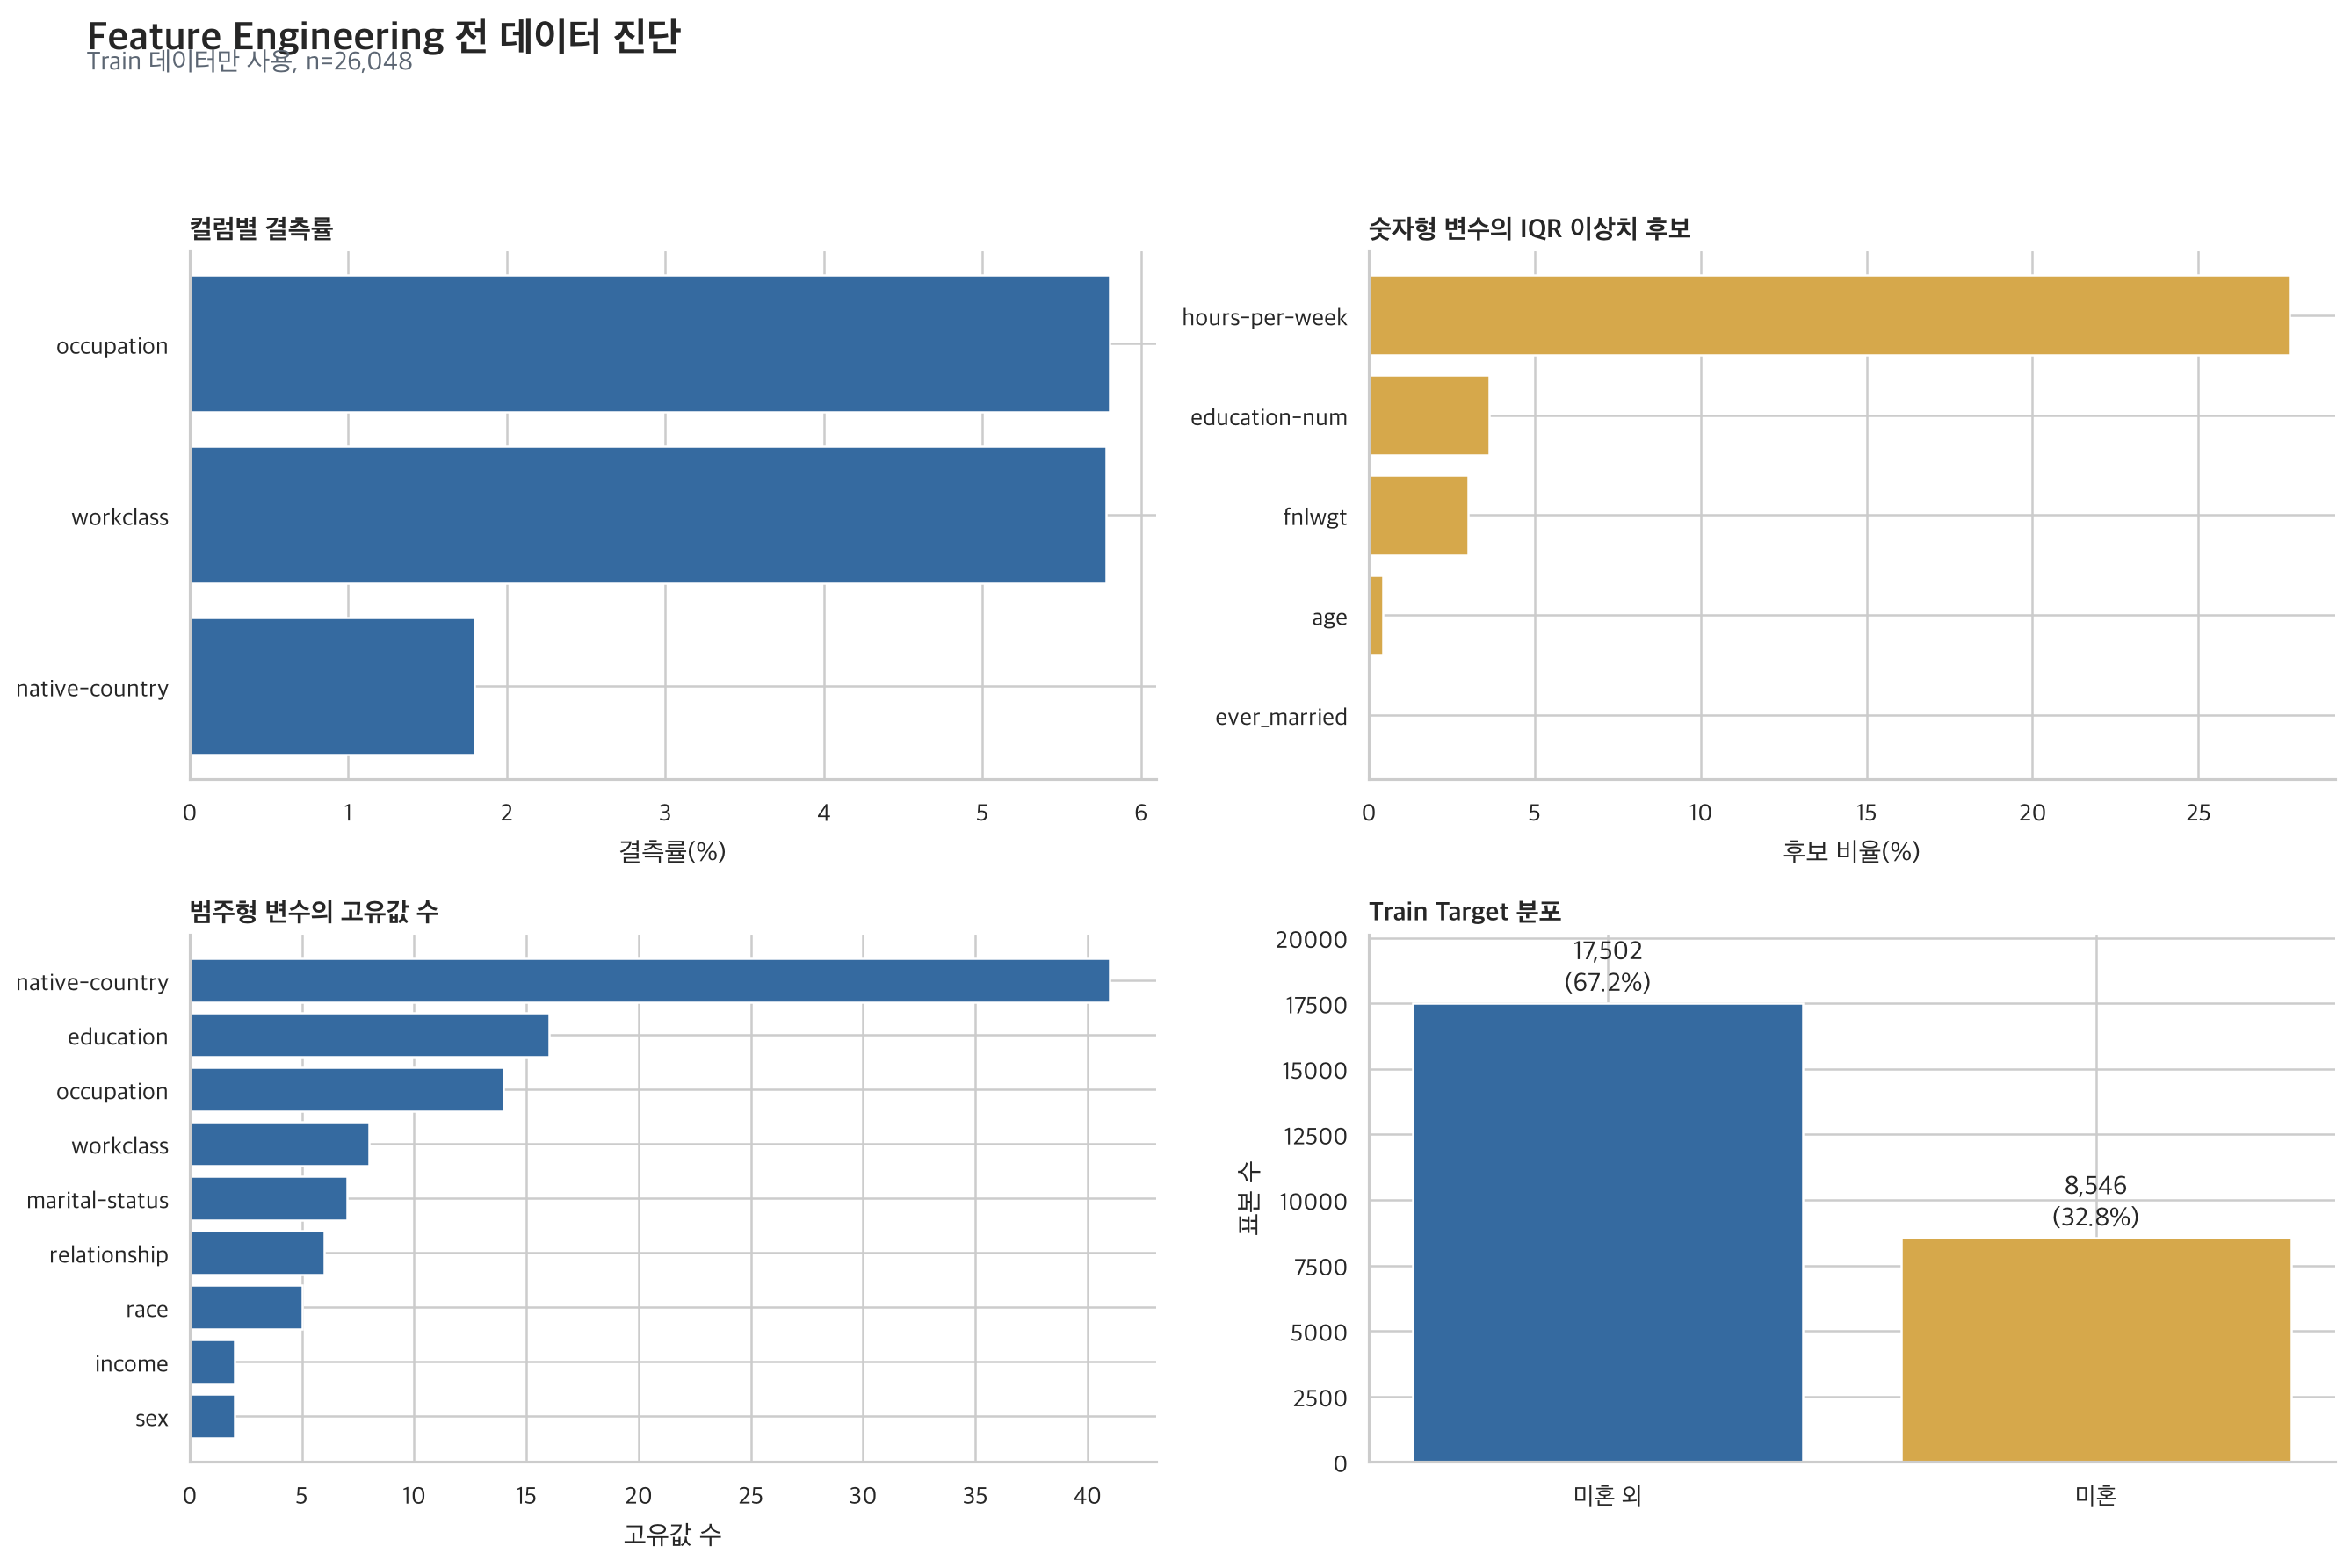

In [4]:
audit_chart_path = create_feature_audit_chart(
    train_df, feature_audit, project_root / 'reports' / 'figures' / '04_feature_audit.png'
)
display(Image(filename=str(audit_chart_path)))

![Feature Engineering 전 데이터 진단](../reports/figures/04_feature_audit.png)

### 2. 처리 의사결정 로그

In [5]:
feature_decisions = build_feature_decisions(train_df)
feature_decisions.to_csv(project_root / 'reports' / 'tables' / 'feature_engineering_decisions.csv', index=False)
feature_decisions

,점검 항목,관찰,결정,근거
0,완전 중복 행,17행,유지,개인 식별자가 없어 동일한 특성의 서로 다른 사람일 수 있음
1,범주형 결측치,"workclass 5.78%, occupation 5.80%",최빈값 대치,Train에서만 최빈값을 학습하고 Test에는 transform만 적용
2,수치형 이상치,IQR 기준 후보가 존재,일괄 삭제 안 함,Adult의 나이·근무시간·자본소득 극단값은 가능한 실제 관측값
3,자본소득 분포,capital-gain 0 비율 91.6%,log1p 파생값 사용,0을 보존하면서 긴 오른쪽 꼬리를 완화
4,범주형 인코딩,명목형 범주,One-Hot Encoding,Label Encoding의 임의 순서 정보를 만들지 않음
5,희소 범주,occupation·workclass 등에 저빈도 범주 존재,1% 미만 통합,OneHotEncoder(min_frequency=0.01)로 Train 기준 통합
6,수치형 스케일,단위와 범위가 서로 다름,StandardScaler,로지스틱 회귀 계수·정규화가 스케일에 좌우되지 않도록 함
7,Target 불균형,"미혼 외 67.2%, 미혼 32.8%",재표본화 안 함,두 집단이 충분히 균형적이며 불필요한 합성·삭제를 피함


## Results

### 3. 이상치와 긴 꼬리 분포

`capital-gain`과 `capital-loss`는 0이 매우 많고 큰 양수 값이 드뭅니다. 실제 가능한 값이므로 삭제하지 않고 `log1p` 파생값을 사용합니다.

In [6]:
skew_before_after = pd.DataFrame({
    '변수': ['capital-gain', 'capital-loss'],
    '변환 전 왜도': [train_df['capital-gain'].skew(), train_df['capital-loss'].skew()],
    'log1p 후 왜도': [np.log1p(train_df['capital-gain']).skew(), np.log1p(train_df['capital-loss']).skew()],
})
skew_before_after.round(3)

,변수,변환 전 왜도,log1p 후 왜도
0,capital-gain,11.751,3.084
1,capital-loss,4.574,4.306


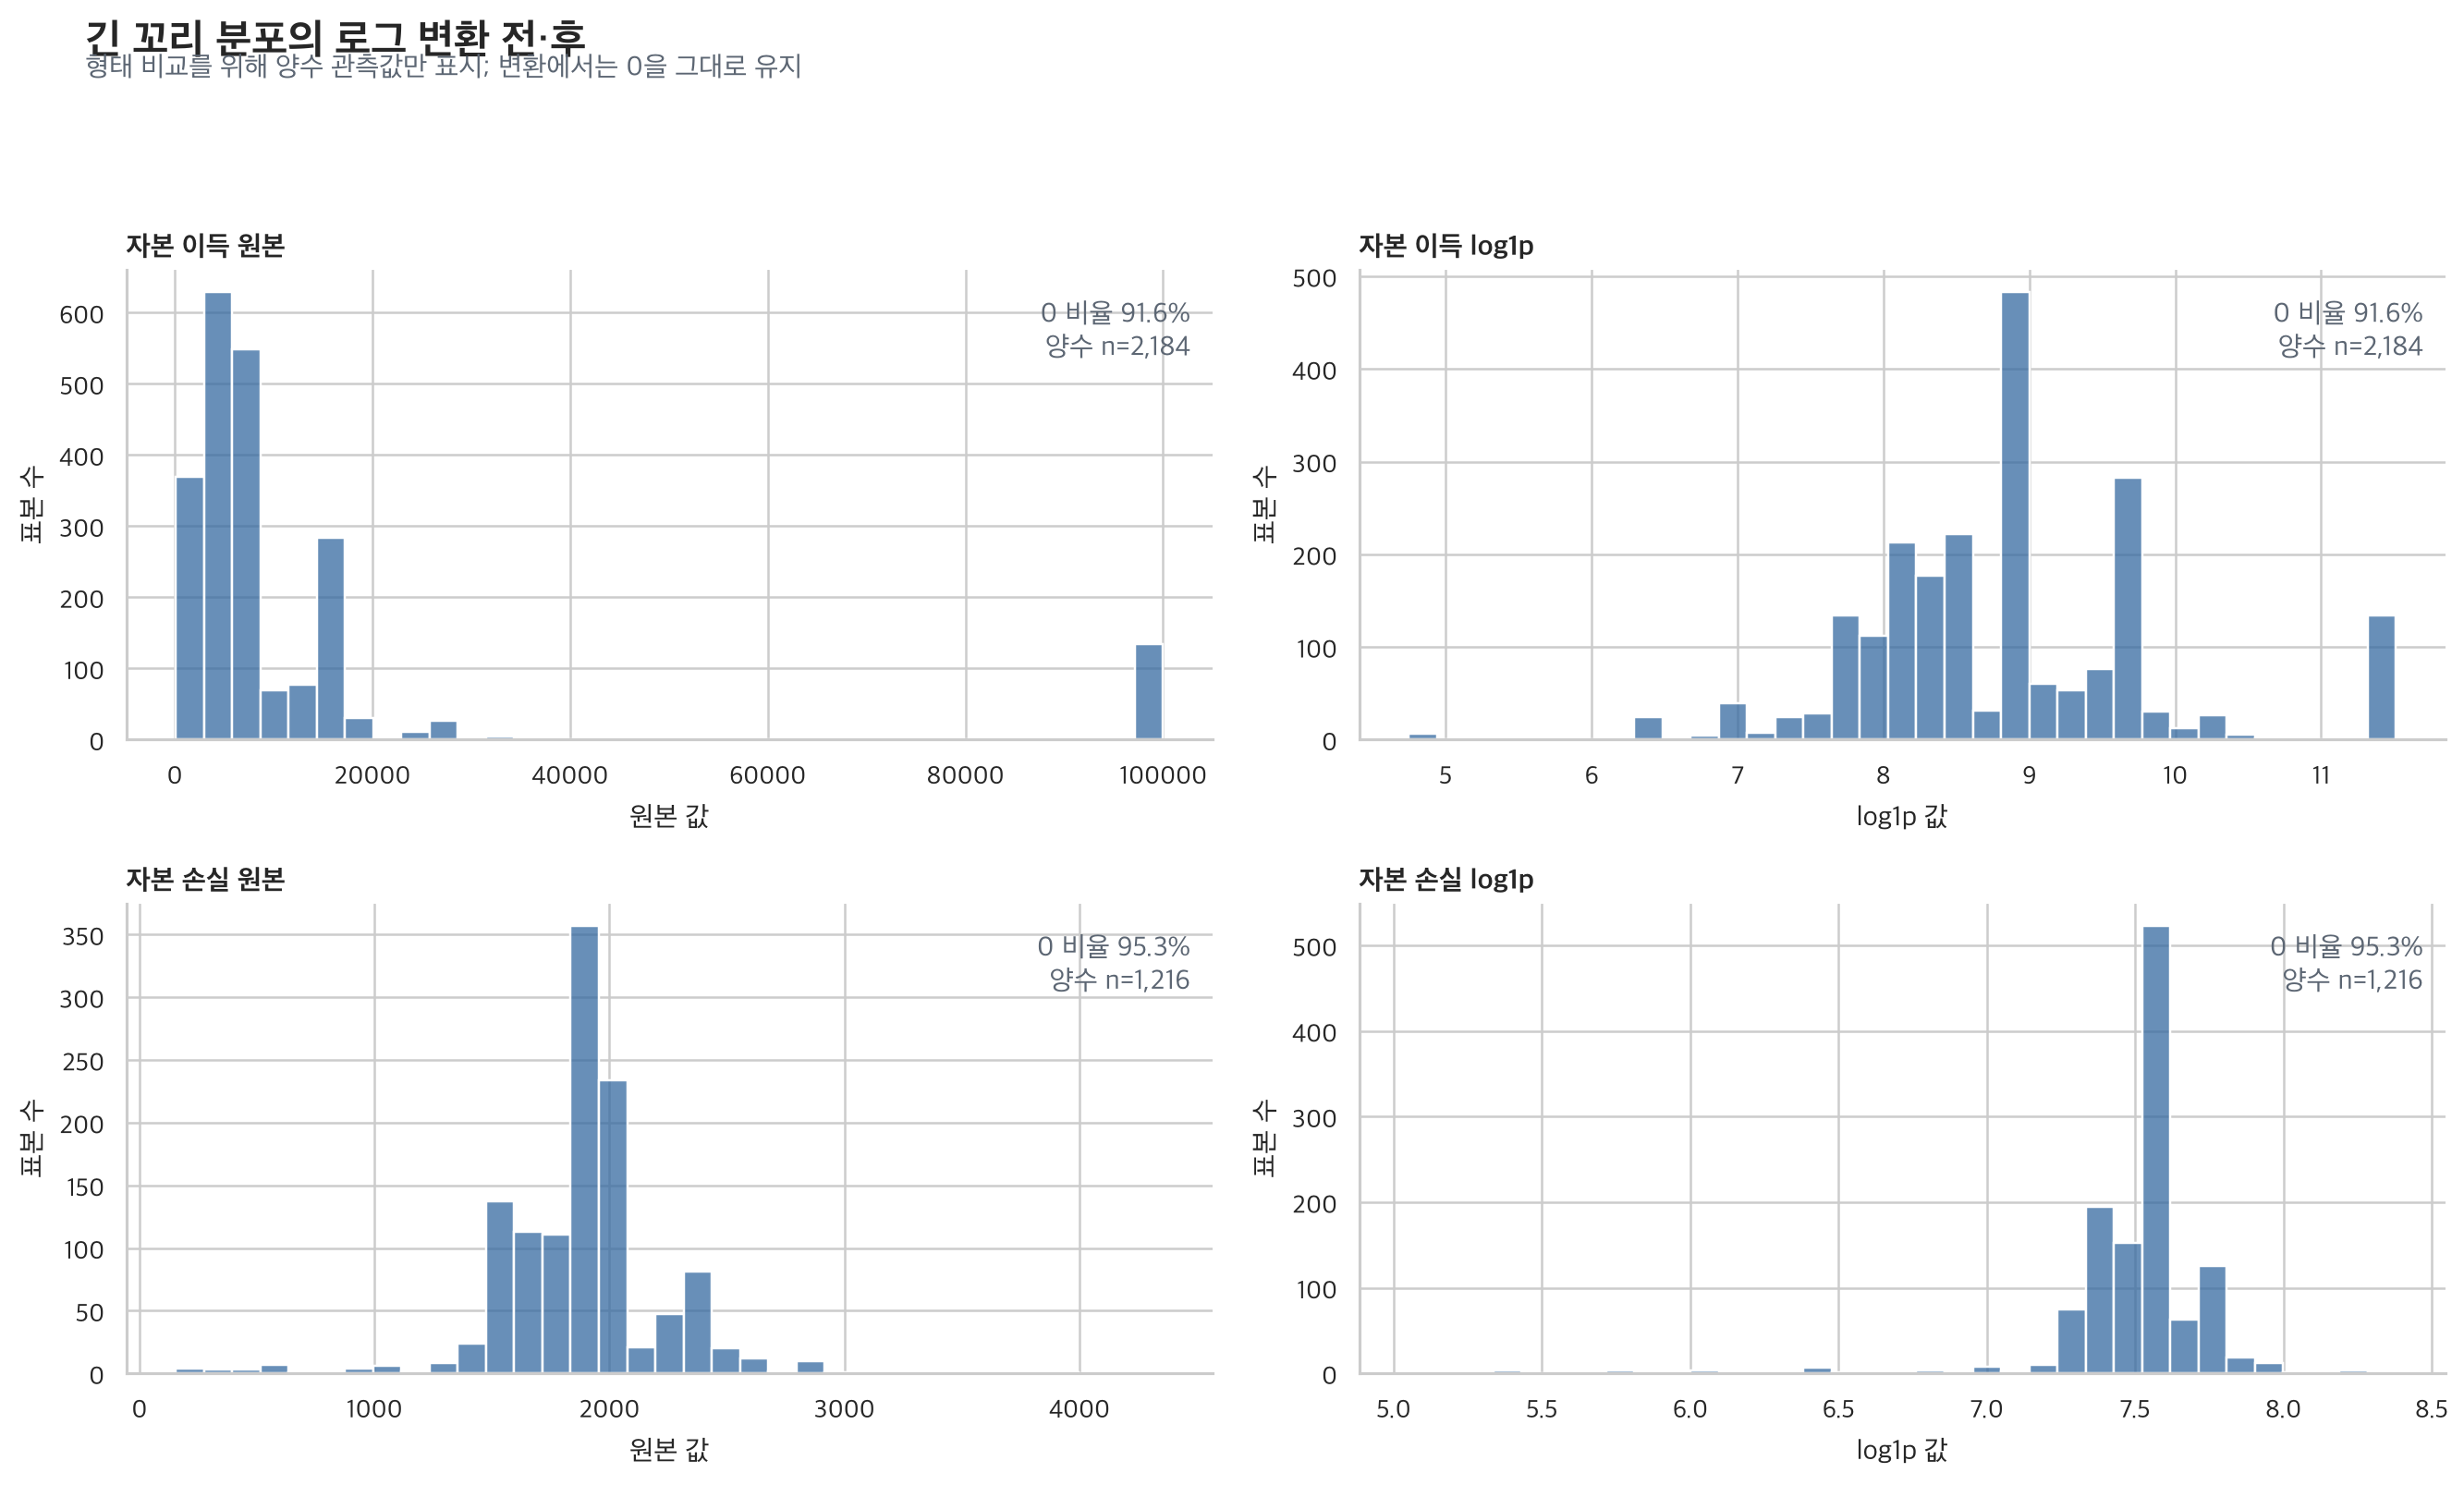

In [7]:
transformation_chart_path = create_transformation_chart(
    train_df, project_root / 'reports' / 'figures' / '04_log_transformation.png'
)
display(Image(filename=str(transformation_chart_path)))

![긴 꼬리 분포의 로그 변환 전후](../reports/figures/04_log_transformation.png)

### 4. 질문에서 파생변수 만들기

- 연령대: 연령의 비선형적 차이를 보기 위한 고정 구간화
- 근무시간대: 표준 근무시간 전후의 차이를 보기 위한 고정 구간화
- 자본 순이득: 자본 이득과 손실을 함께 표현한 signed-log 변수

구간 경계는 전체 데이터 분포에서 학습하지 않은 고정 업무 규칙이므로 Train/Test에 동일하게 적용할 수 있습니다.

In [8]:
engineered_train = engineer_features(train_df)
engineered_train[[
    'age', 'age-group', 'hours-per-week', 'hours-group',
    'capital-gain-log', 'capital-loss-log', 'capital-net-signed-log'
]].head(10)

,age,age-group,hours-per-week,hours-group,capital-gain-log,capital-loss-log,capital-net-signed-log
0,39,30대,40,주 35~40시간,7.684784,0.0,7.684784
1,50,50대,13,주 34시간 이하,0.000000,0.0,0.000000
2,38,30대,40,주 35~40시간,0.000000,0.0,0.000000
3,53,50대,40,주 35~40시간,0.000000,0.0,0.000000
4,28,20대 이하,40,주 35~40시간,0.000000,0.0,0.000000
5,37,30대,40,주 35~40시간,0.000000,0.0,0.000000
7,52,50대,45,주 41~50시간,0.000000,0.0,0.000000
9,42,40대,40,주 35~40시간,8.552367,0.0,8.552367
10,37,30대,80,주 51시간 이상,0.000000,0.0,0.000000
11,30,30대,40,주 35~40시간,0.000000,0.0,0.000000


### 5. 스케일링 비교

Min-Max, Standard, Robust를 모두 눈으로 비교합니다. 최종 Pipeline은 로지스틱 회귀의 계수와 정규화가 단위 차이에 좌우되지 않도록 `StandardScaler`를 사용합니다. 자본소득은 먼저 로그 변환하여 긴 꼬리를 완화합니다.

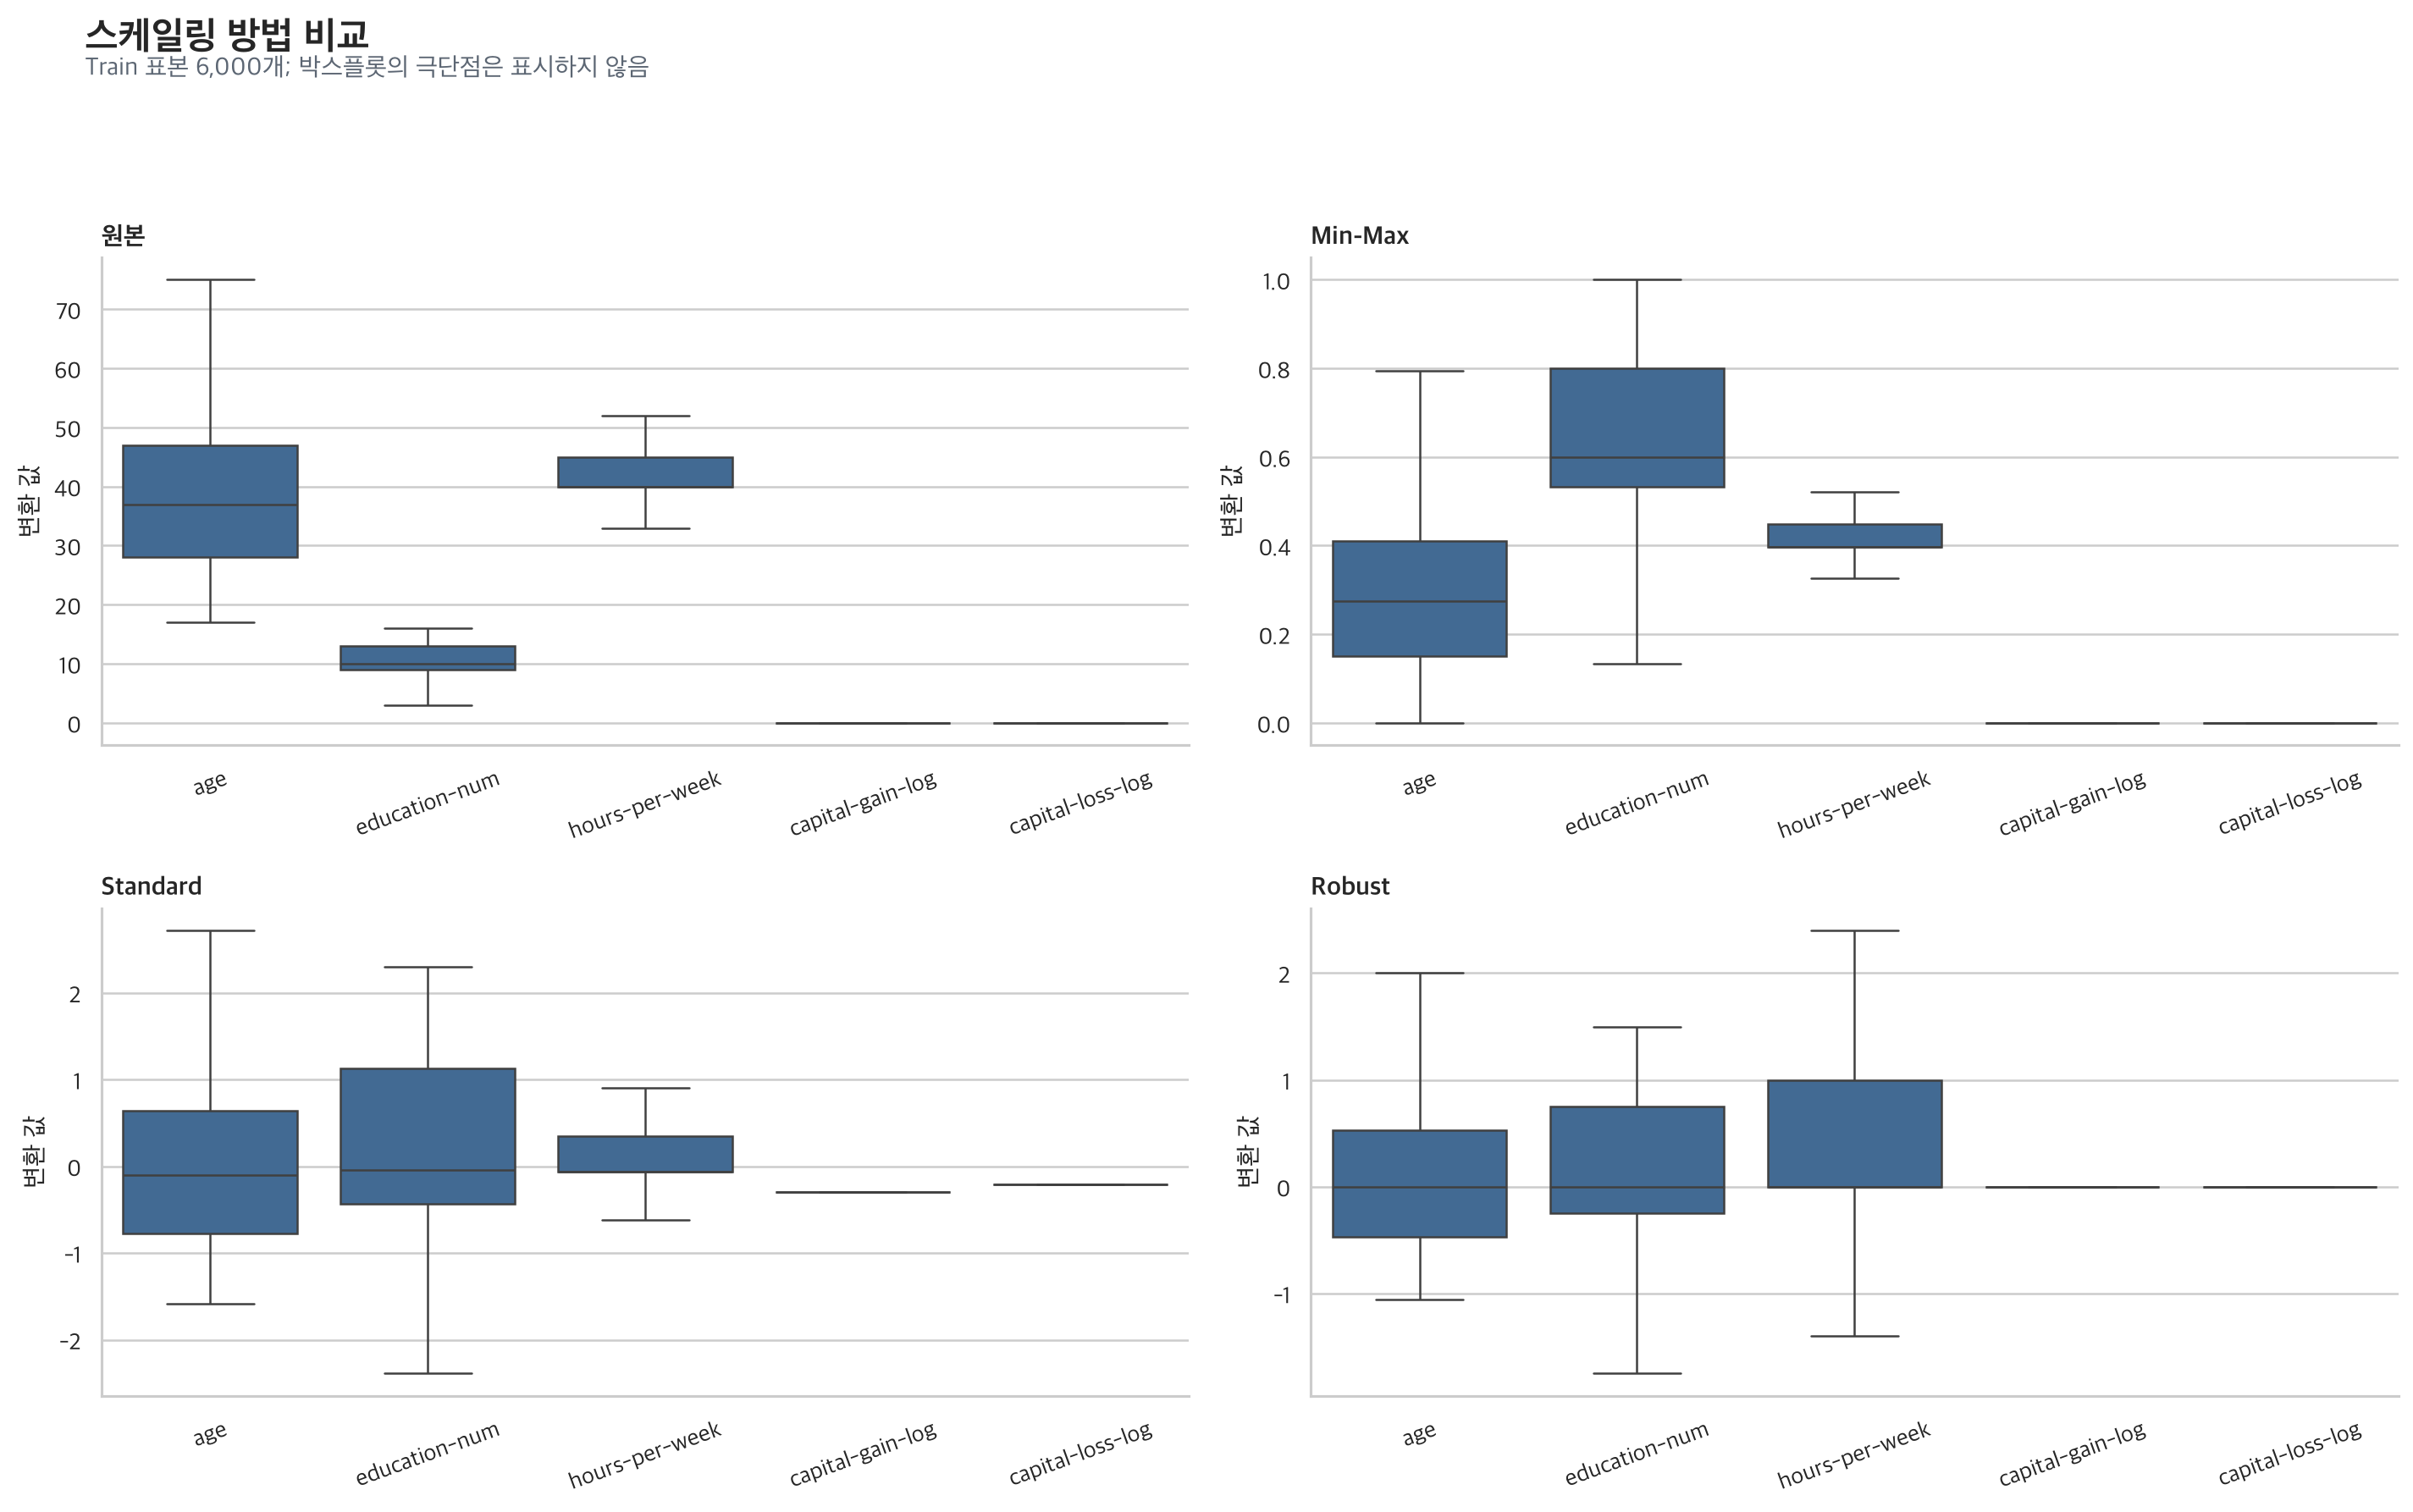

In [9]:
scaling_chart_path = create_scaling_comparison_chart(
    train_df, project_root / 'reports' / 'figures' / '04_scaling_comparison.png'
)
display(Image(filename=str(scaling_chart_path)))

![스케일링 방법 비교](../reports/figures/04_scaling_comparison.png)

### 6. 인코딩과 전체 Pipeline

명목형 변수에 Label Encoding을 쓰면 존재하지 않는 순서가 생기므로 One-Hot Encoding을 사용합니다. Train에서 1% 미만인 희소 범주는 자동 통합하고, 첫 범주는 기준 범주로 제외합니다.

In [10]:
preprocessing_pipeline = build_preprocessing_pipeline()
X_train = train_df.drop(columns=[TARGET])
X_test = test_df.drop(columns=[TARGET])
X_train_transformed = preprocessing_pipeline.fit_transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)
feature_names = transformed_feature_names(preprocessing_pipeline)
print('변환 전:', X_train.shape, X_test.shape)
print('변환 후:', X_train_transformed.shape, X_test_transformed.shape)
print('출력 Feature 예시:', feature_names[:12])

변환 전: (26048, 15) (6513, 15)
변환 후: (26048, 32) (6513, 32)
출력 Feature 예시: ['numeric__age', 'numeric__education-num', 'numeric__hours-per-week', 'numeric__capital-gain-log', 'numeric__capital-loss-log', 'numeric__capital-net-signed-log', 'categorical__workclass_Local-gov', 'categorical__workclass_Private', 'categorical__workclass_Self-emp-inc', 'categorical__workclass_Self-emp-not-inc', 'categorical__workclass_State-gov', 'categorical__workclass_infrequent_sklearn']


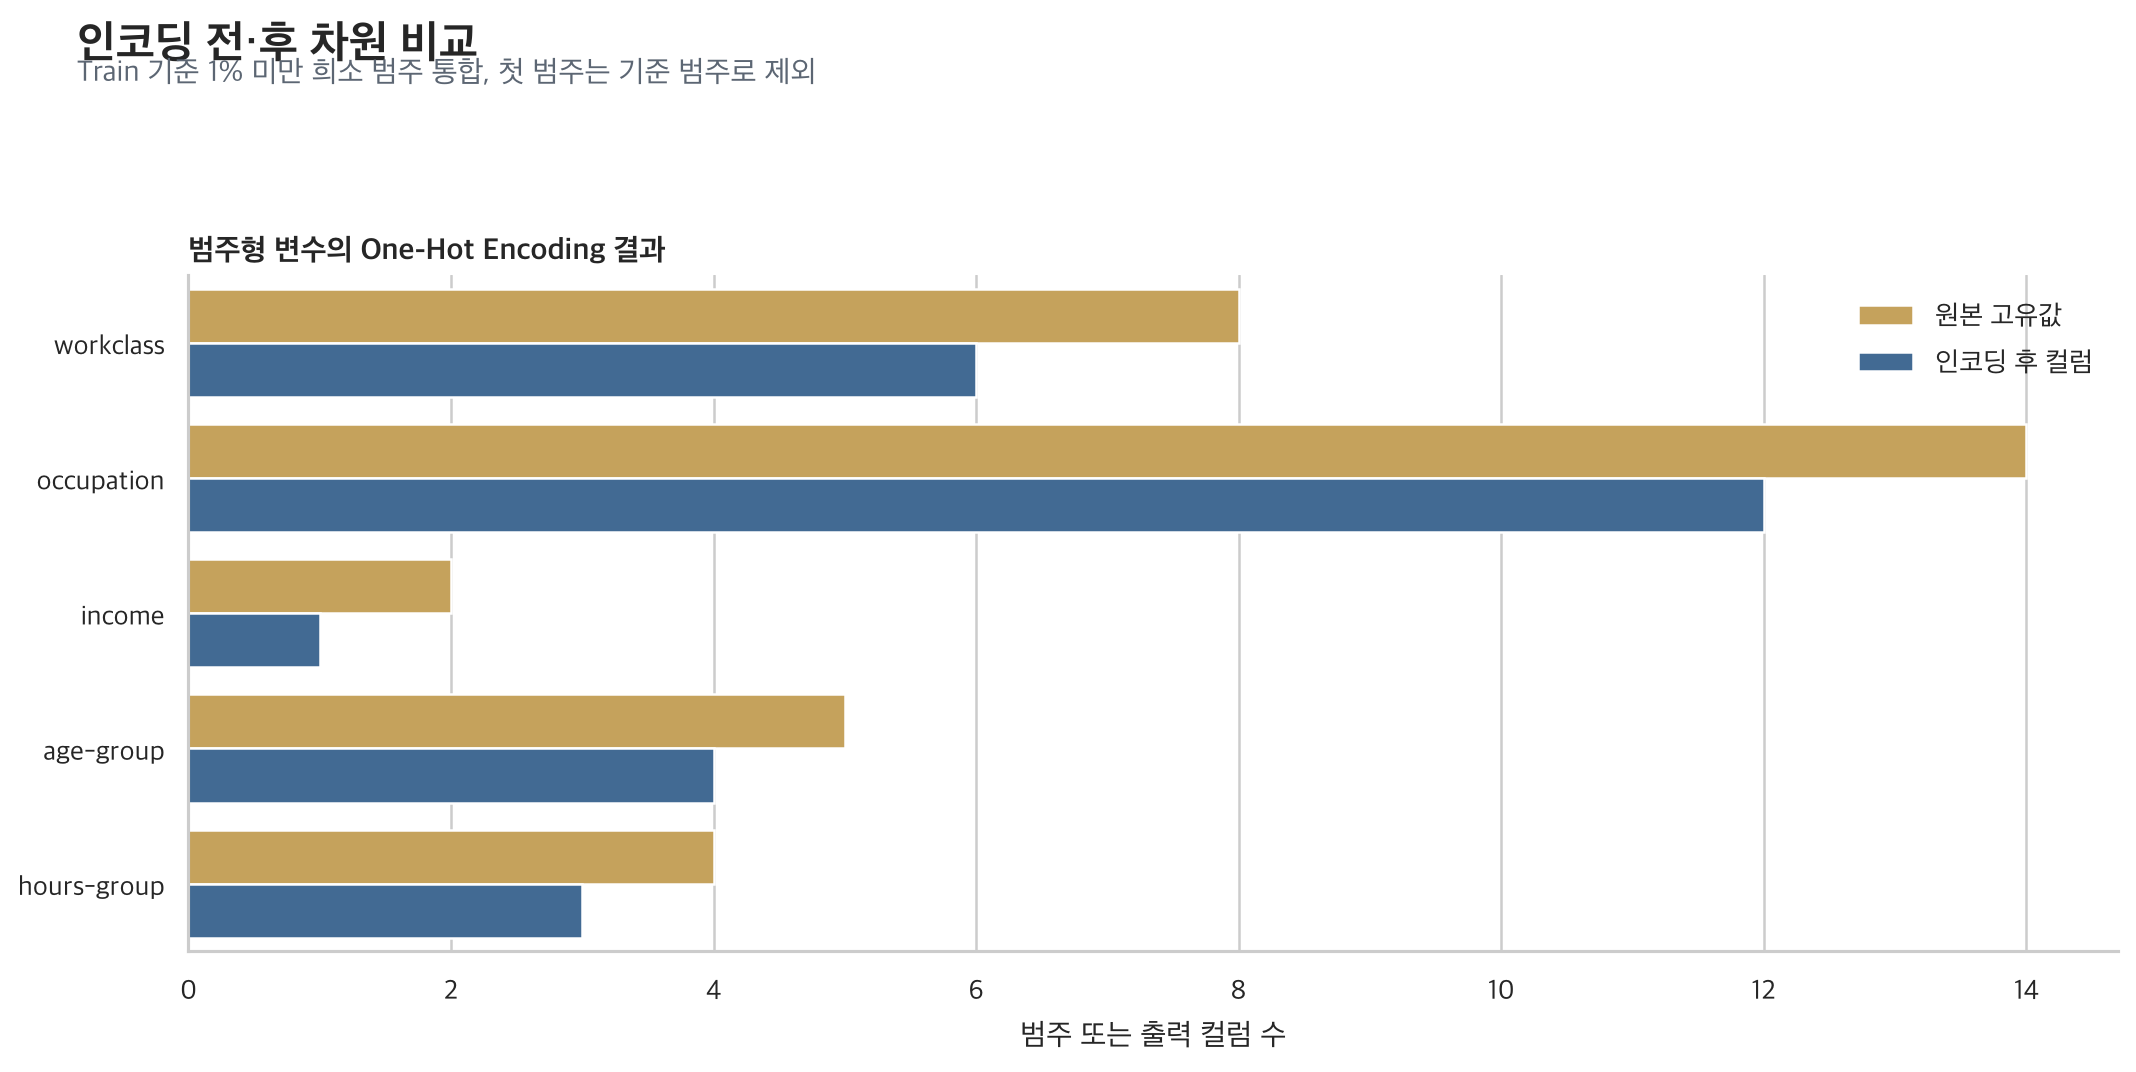

In [11]:
encoding_chart_path = create_encoding_summary_chart(
    train_df, feature_names, project_root / 'reports' / 'figures' / '04_encoding_summary.png'
)
display(Image(filename=str(encoding_chart_path)))

![인코딩 전후 차원 비교](../reports/figures/04_encoding_summary.png)

### 7. 변환 결과 품질 검증

In [12]:
transformed_train_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
transformed_test_df = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)
quality_checks = pd.DataFrame([{
    'Train 행 수 보존': len(transformed_train_df) == len(train_df),
    'Test 행 수 보존': len(transformed_test_df) == len(test_df),
    'Train/Test 컬럼 수 일치': transformed_train_df.shape[1] == transformed_test_df.shape[1],
    'Train 결측치 0개': int(transformed_train_df.isna().sum().sum()) == 0,
    'Test 결측치 0개': int(transformed_test_df.isna().sum().sum()) == 0,
    '무한대 없음': np.isfinite(X_train_transformed).all() and np.isfinite(X_test_transformed).all(),
}])
quality_checks

,Train 행 수 보존,Test 행 수 보존,Train/Test 컬럼 수 일치,Train 결측치 0개,Test 결측치 0개,무한대 없음
0,True,True,True,True,True,True


## Takeaways

- 결측치는 삭제하지 않고 Pipeline 내부에서 Train 기준으로 대치합니다.
- IQR 이상치 후보는 실제 가능한 값이므로 일괄 삭제하지 않습니다.
- 자본소득 변수는 log1p/signed-log로 긴 꼬리를 완화합니다.
- 범주형은 희소 범주 통합 후 One-Hot Encoding, 수치형은 Standard Scaling을 적용합니다.
- Target 분포를 확인한 결과 한쪽이 극단적으로 희소하지 않아 SMOTE나 undersampling을 적용하지 않습니다.
- 검증 결과 Train 26,048행·Test 6,513행이 32개 Feature로 변환되며 결측치는 모두 0개였습니다.
- 다음 모델링 단계에서는 이 전처리 Pipeline 뒤에 로지스틱 회귀를 연결하면 데이터 누수를 막을 수 있습니다.

In [13]:
assert quality_checks.all(axis=None)
for path in [audit_chart_path, transformation_chart_path, scaling_chart_path, encoding_chart_path]:
    assert path.exists()
print('검증 완료: Feature Engineering Pipeline이 Train/Test에 정상 적용됐습니다.')

검증 완료: Feature Engineering Pipeline이 Train/Test에 정상 적용됐습니다.
